# California Housing Prices Prediction
> Learning project following *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* by
**Aurélien Géron** (Chapter 2).

## 1. Frame the Problem & Objectives
* **Dataset**: [California Housing Dataset](https://github.com/ageron/data/tree/main/housing) (1990 California census data).
* **Target**: Predict a district's **median house value**.

### Key Observations & Design Decisions
* **Supervised Learning**: Target labels are available in the training data.
* **Multiple Univariate Regression**: Uses multiple predictor features (income, location, total rooms, etc.) to predict a single continuous output.
* **Batch Learning**: Small static dataset with no continuous incoming data stream.
* **Performance Measure**: **RMSE** (Root Mean Squared Error) will be used as the evaluation metric.

In [4]:

#Load the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame
import seaborn as sns

### Load data
* I have loaded data from the url link provided in the code as downloading data and statically importing it is not good practice. What I have done is (as given is book):
    * I check if the data already exists or not.
    * if it does then well just read it.
    * if not then download .tgz archive from link and then extract it.

In [5]:
#import needed for below function
#for path defining
from pathlib import Path
#to extract data

import tarfile
#to retrieve data from given url
import urllib.request

In [7]:
# function to load the data

def load_housing_data() ->  DataFrame:
    #define zip file path
    zip_path = Path('data/housing_data.tgz')
    if not zip_path.is_file():

        #if zip path not found
        #make data directory if it doesn't exist
        Path('data').mkdir(parents=True , exist_ok=True)

        #data on web
        url = 'https://github.com/ageron/data/raw/main/housing.tgz'

        #retrieve the file in zip_path location
        urllib.request.urlretrieve(url , zip_path)

        #extract the data bcs this is first load so this is done inside if condition
        with tarfile.open(zip_path) as housing_zip:
            housing_zip.extractall(path='data',filter='data')

    #return the dataframe
    return pd.DataFrame(pd.read_csv(Path("data/housing/housing.csv")))


In [8]:
#Load data in var
housing_df = load_housing_data()

### EDA (exploratory data analysis)
#### Try to understand the Data

In [9]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [10]:
#column info
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [11]:
# finding null values
housing_df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [12]:
# analyzing categories in the ocean_proximity
#counting value for each unique category
housing_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [13]:
#summary statistics using describe()
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### Observations
* total 10 features 9 input and 1 target
* column 'total_bedrooms' contain 207 null/missing values
* One categorical Column 'ocean_proximity' with labels : ['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
* Target column is 'median_house_value'
* 'median_income' is preprocessed scaled so that 3 is roughly equal to \$30000.

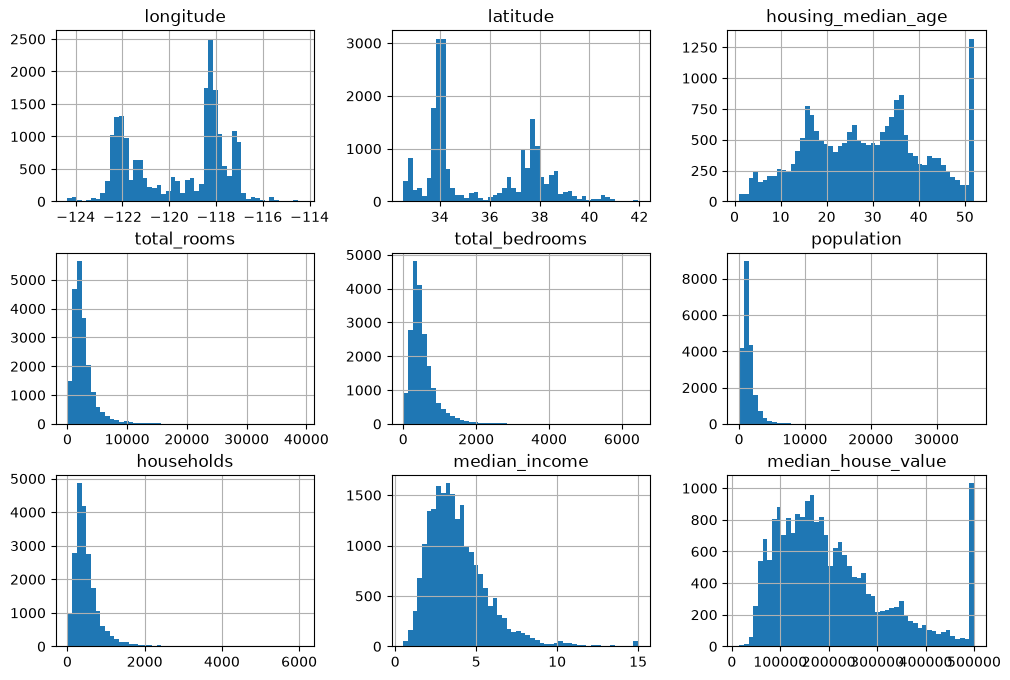

In [14]:
#analyzing each numerical columns using histo grams
housing_df.hist(bins=50 , figsize=(12,8))
plt.show()

### Splitting the Data

* when trying to split the data we can use train_test_split() of sklearn but this function creates the test set with complete randomness
* This is okay for most of the models but the real problem is that it is not gurenteed that the test split represents the data accurately.

* **What would be the best approach?**
    * For example, we have a dataset having 54 % male and 46% females in it.
    * So, for a test split the ideal sample will be the sample in which the percentage of the male and female is same as in total population
    * i.e. for a sample of 1000 it would be better if it has near to 540 males and 460 females.
    * **This splitting is Know as _stratified sampling_**
<br>
* Now, in book it is recommended and is also obvious that the `median_income` column is very important attribute to predict the target. So,we make sure the test is representative of the given attribute.

* To achieve this will split make a categorical attribute `income_cat` which represents income category with binwidth = 1.5 roughly \$15,000.

* Based on this attribute we will stratify the test split as given in below code cell.

**Note :-**
* We can try to make a function which gives use n number of this train test split; which may be helpful in the feature.
 * for reference see HOML book page 61 .

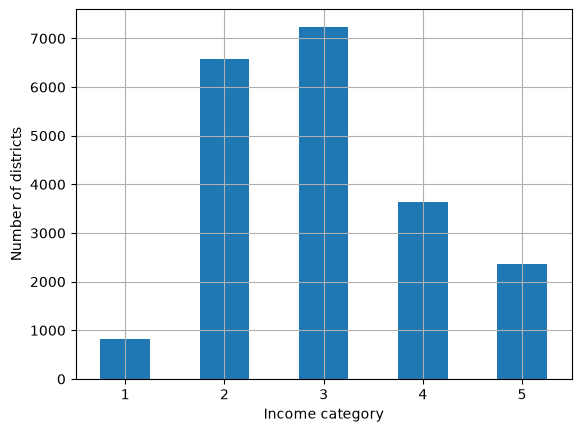

In [15]:
#making 'income_cat' column
housing_df['income_cat'] = pd.cut(housing_df['median_income'] ,
                                  bins = [0 , 1.5 , 3.0 , 4.5 , 6.0 , max(housing_df['median_income'])],
                                  labels = [1,2,3,4,5])

## To see the distribution of the income in different bins ##
#return the categories
cat_counts = housing_df['income_cat'].value_counts().sort_index()
cat_counts.plot.bar(rot =0 ,grid = True)
plt.xlabel('Income category')
plt.ylabel('Number of districts')
plt.show()

In [16]:
#train test split
from sklearn.model_selection import train_test_split

train_data , test_data = train_test_split(housing_df , test_size=0.2, stratify=housing_df['income_cat'], random_state=42)

#better to drop 'income_cat' as it has no use now

train_data.drop('income_cat' , axis = 1, inplace = True)
test_data.drop('income_cat' , axis = 1, inplace = True)

# copy to experiment on
train_data_c= train_data.copy()
test_data_c= test_data.copy()

In [17]:
# function for multiple tarin_test_splits

from sklearn.model_selection import StratifiedShuffleSplit

#making this usable by using these arguments rather than hardcoding it
def strat_train_test_multiple(df: pd.DataFrame , split_col: str , n: int = 10):
    splitter = StratifiedShuffleSplit(n_splits=n ,
                                      test_size=0.2,
                                      random_state=42)

    strat_splits = []

    #split() return the idx of the train and test splits only
    for train_idx,test_idx in splitter.split(df ,
                                       df[split_col]):
        #splitting by index returned
        strat_train_set_n = df.iloc[train_idx]
        strat_test_set_n = df.iloc[test_idx]
        #used tuple to pack them.
        strat_splits.append((strat_train_set_n,strat_test_set_n))

    return strat_splits

#### Correlation analysis
* A correlation analysis is a very important part in EDA where learn how the variables depend on each other.
* i.e. how change in one variable affects change in the other variable.
* We will use pearsons correlation coefficient which helps identify the linear relationship between two numeric features. But, it ignores any non-linear relationship in vars.
* its value is between -1 and 1. The closer it is to 1 or -1 the linear relationship is also strong and closer it is to zero less correlation between features.
* This part is very helpful in feature engineering.
* We will build a correlation matrix for this and correlation of each input features to the output feature.

**Note :-**
* We can also do correlation analysis using scatter plots.
* I am skipping that part which is given in the book.

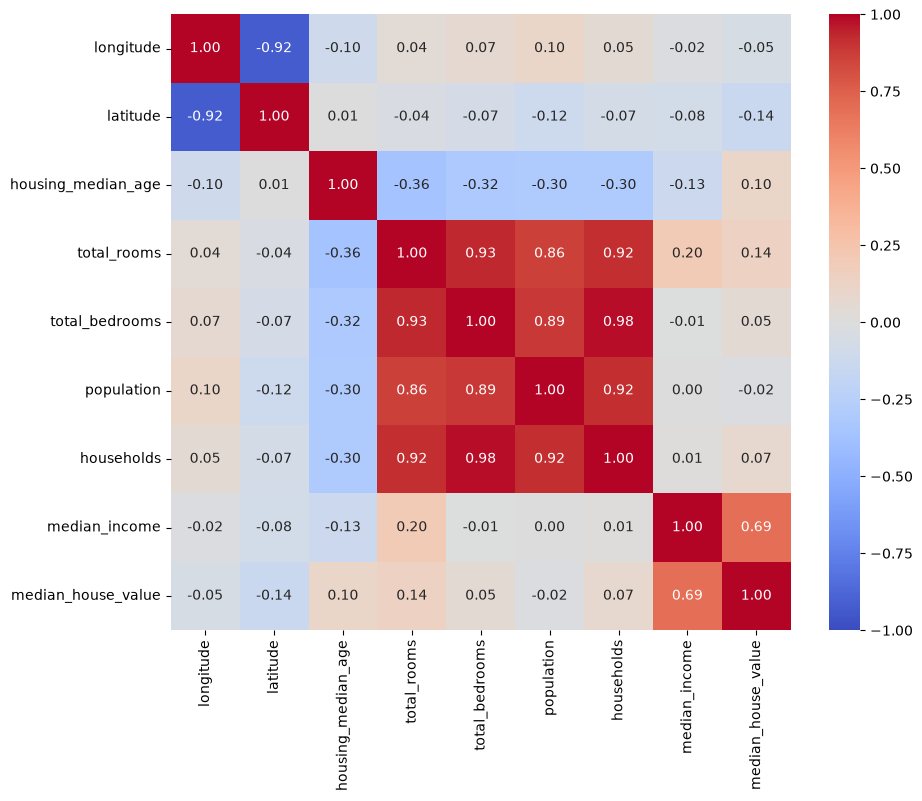

In [18]:
# all analysis in training data

plt.figure(figsize=(10,8))

corr_matrix = train_data_c.corr(numeric_only=True)

# Heat map for better appealing visuals
sns.heatmap(corr_matrix , annot=True , cmap='coolwarm' , fmt = '.2f' , vmin = -1 , vmax = 1)

plt.show()

* We came to know that whole correlation matrix is very overwhelmin to look at.
* The solution is to find the features which are more related to the target then fing correlation between those main features.

In [19]:
# find each feature corr with median_house_value
print(corr_matrix['median_house_value'].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


* the Features are not very correlated.
* The top most features that will be useful for prediction of the target will be `median_income`,`total_rooms` ,`housing_median_age` and `latitude`.
* Taken features having corr > 0.1 or < -0.1

### Feature Engineering

* In feature engineering we try to identify the features that are useful for as input features and also to create new features from existing features which may convey more information than existing features.
* In this project we saw that existing features have very low correlation with target.
* Features that might be good are `total_rooms_per_household` , `bedrooms_per_total_rooms`  and `people_per_household`.

In [20]:
#making new features

train_data_c['rooms_per_house'] = train_data_c['total_rooms'] / train_data_c['households']
train_data_c['bedroom_ratio'] = train_data_c['total_bedrooms'] / train_data_c['total_rooms']
train_data_c['people_per_house'] = train_data_c['population'] / train_data_c['households']

In [21]:
# new correlation analysis
corr_matrix = train_data_c.corr(numeric_only=True)

print(corr_matrix['median_house_value'].sort_values(ascending=False))

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedroom_ratio        -0.256397
Name: median_house_value, dtype: float64


* we can observe that `bedroom_ratio` is more correlated than the other existing attributes and `rooms_per_house` is also more correlated than total_rooms and households.

**Note :-**
* We have to be careful in selecting the attributes if two attributes are too much correlated then the probability that model overfits increases, So we will choose only one of the two having bigger correlation magnitude with the target variable.

* In this we will choose the attributes `[median_income , rooms_per_house , total_rooms , housing_median_age ,latitude ,bedroom_ratio]` and check the correlation between this attributes using heat map.

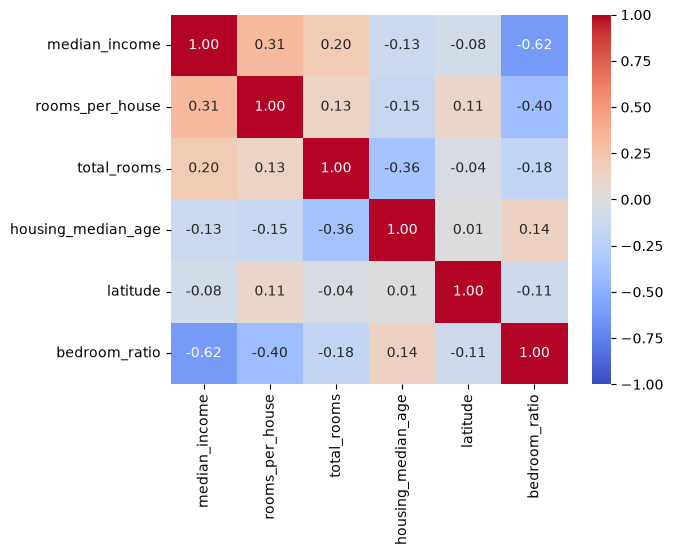

In [22]:
# heatmap of attributes chosen

temp = train_data_c[['median_income' , 'rooms_per_house' , 'total_rooms' , 'housing_median_age' ,'latitude' ,'bedroom_ratio']].corr(numeric_only=True)

sns.heatmap(temp , annot=True , cmap='coolwarm' , fmt = '.2f' , vmin = -1 , vmax = 1)

plt.show()

* We observe that the attributes are not very much correlated to each other.
* because all attribute have correlation coefficient magnitude < 0.8 so all attributes can be used.

> [!NOTE]
> **Learning Context: Manual Feature Engineering**
> The feature transformations created above (e.g., `rooms_per_house`, `bedroom_ratio`) were performed
**manually** on a copy of the training set (`train_data_c`) for exploratory and learning purposes.
>
> In a production machine learning pipeline, manual transformations are prone to errors and data leakage.
  Later in this chapter, we will learn how to **automate** this process by writing custom Scikit-Learn
  Transformers and Pipelines (specifically using the `CombinedAttributesAdder` class), which will allow us to
  cleanly replicate these transformations across training, testing, and future live data.

### Feature Transformation
* There are many important reasons as to why we require to transform the features of the data
    * Data is skewed
    * Numeric columns with high skewness and different scales
    * Making new features
    * transforming categorical features to numerical features
    * Data cleaning also needed

##### Transformation needed in this Project

* Missing values in numerical features will be imputed by replacing them with the median, as most ML algorithms don’t expect missing values. In categorical features, missing values will be replaced by the most frequent category.
* The categorical feature will be one-hot encoded, as most ML algorithms only
accept numerical inputs.
* A few ratio features will be computed and added: `bedrooms_ratio`, `rooms_per_house`, and `people_per_house`. Hopefully these will better correlate with
the median house value, and thereby help the ML models.
* A few cluster similarity features will also be added. These will likely be more useful to the model than latitude and longitude.
* Features with a long tail will be replaced by their logarithm, as most models prefer features with roughly uniform or Gaussian distributions.
* All numerical features will be standardized, as most ML algorithms prefer when all features have roughly the same scale.

**NOTE :-**
* We are going to create diiferent pipelines as needed and will use columnTransformation on this. We will try to make a preprocessing function which will handle all the cleanup and also transformation.

#### The Transformers needed
* Ratio transformers for making new features
* One hot encoders
* Log transformation
* Scalers
* Imputers
* and Similarity clusters, A very intuitive topic for more refer book chapter 2 page 79 RBF.

In [23]:
# imports needed
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics.pairwise import rbf_kernel

from sklearn.impute import SimpleImputer

from sklearn.pipeline import make_pipeline

from sklearn.cluster import KMeans

from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin

from sklearn.compose import ColumnTransformer, make_column_selector


In [24]:
# For column creation
def column_ratio(X):
    return X[:,[0]] / X[: , [1]]

def ratio_name(function_transformer , feature_names_in):
    return ['ratio'] # feature names out

ratio_pipeline = make_pipeline(
                    SimpleImputer(strategy='median'), ## impute any missing value
                    FunctionTransformer(column_ratio , feature_names_out=ratio_name), #what values will be in them
                    StandardScaler() #for scaling
                )

In [25]:
# for numerical columns

log_pipeline = make_pipeline(
                    SimpleImputer(strategy='median'), # impute the missing values
                    #Log-transformation
                    FunctionTransformer(np.log1p , feature_names_out='one-to-one'), # same name of features # we igonre giving inverse function auto detected?
                    StandardScaler()
                )

#### Custom Transformer: ClusterSimilarity
   * **Purpose**: Groups geographical coordinates (latitude and longitude) into spatial clusters based on proximity, resolving the challenge of raw coordinate features being hard for ML models to interpret.
   * **Fit Step**: Trains `KMeans` on the coordinates to find $N$ cluster centroids (representing regional geographic hubs).
   * **Transform Step**: Uses `rbf_kernel` (Radial Basis Function) to measure the spatial similarity between each district and the learned cluster centers, outputting $N$ new similarity features (ranging from $0.0$ for far away to $1.0$ for exactly on the center).

In [26]:
# for the clustering of longitude and latitude for better use of those features
class ClusterSimilarity(BaseEstimator , TransformerMixin):
    def __init__(self , n_clusters=10, gamma=1.0 ,random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self , X, y=None , sample_weight=None):
        self.kmeans_ = KMeans(n_clusters=self.n_clusters , random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self , X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_,gamma=self.gamma)

    def get_feature_names_out(self,names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

cluster_simil = ClusterSimilarity(n_clusters=10 , gamma=1. , random_state=42)

In [27]:
#default num pipeline for a normal numeric pipeline which may not require a log transformation
default_num_pipeline = make_pipeline(
                            SimpleImputer(strategy='median'),
                            StandardScaler()
                        )

In [28]:
# categorical column pipeline

cat_pipeline = make_pipeline(
                    SimpleImputer(strategy='most_frequent'),
                    OneHotEncoder(handle_unknown='ignore')
                )

In [29]:
# the Column Transformer
# argument structure a tuple of 3 args (name , pipeline or transformer , features)
preprocessing = ColumnTransformer([
                    ('bedrooms' , ratio_pipeline , ['total_bedrooms' , 'total_rooms']),
                    ('rooms_per_house' , ratio_pipeline , ['total_rooms' , 'households']),
                    ('people_per_house' , ratio_pipeline , ['population', 'households']),
                    ('log' , log_pipeline , ['total_bedrooms','total_rooms','population',
                                             'households','median_income']),
                    ('geo' , cluster_simil , ['latitude','longitude']),
                    ('cat' , cat_pipeline , make_column_selector(dtype_include=object)),
                ],
                remainder=default_num_pipeline #if any column remaining
            )

In [30]:
## prepared data
## using original train test data
# return an np.array

#extracting features and labels
housing = train_data.drop('median_house_value' , axis = 1)
housing_labels = train_data['median_house_value'].copy()

train_data_prepared = preprocessing.fit_transform(housing)
print(type(train_data_prepared) , train_data_prepared.shape)

<class 'numpy.ndarray'> (16512, 24)


In [31]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

### Model Training
* Now, comes the main part, In this part we make a training loop.
* The training loop will contain pipeline for preprocessing and training on different models.
* And we will also monitor their scores as to how they have performed using `RMSE`.
* After selecting the best model we will finetune it using `RandomizedsearchCV` and will discuss difference in performance if any at all.
* and will analyze different results.

In [32]:
#importing the models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score

from sklearn.metrics import root_mean_squared_error

In [33]:
 # a function that returns a training pipeline with given model

def full_pipeline(model_chosen):
    return Pipeline([
         ('preprocessing', preprocessing),
         ('model' , model_chosen)
    ])

In [34]:
# only Linear Regression without cross validation
train_linear = full_pipeline(LinearRegression())

train_linear.fit(housing , housing_labels)

predictions = train_linear.predict(housing)

print("Linear Regression :" ,  root_mean_squared_error(housing_labels , predictions))

Linear Regression : 67270.1075042873


In [35]:
# only Decision Tree

train_decision_tree = full_pipeline(DecisionTreeRegressor(random_state=42))

train_decision_tree.fit(housing , housing_labels)

predictions = train_decision_tree.predict(housing)

print("Decision Tree regressor :" ,  root_mean_squared_error(housing_labels , predictions))

Decision Tree regressor : 0.0


In [36]:
# only Random Forest Regressor

# use 8 cores for computation using n_jobs
train_random_forest = full_pipeline(RandomForestRegressor(random_state=42 , n_jobs=8))

train_random_forest.fit(housing , housing_labels)

predictions = train_random_forest.predict(housing)

print("Random Forest regressor :" ,  root_mean_squared_error(housing_labels , predictions))

Random Forest regressor : 17520.773449846263


In [42]:
## Training Loop

housing = train_data.drop('median_house_value' , axis = 1)
housing_labels = train_data['median_house_value'].copy()

result = {}

model = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree' : DecisionTreeRegressor(random_state=42),
    'Random Forest' : RandomForestRegressor(random_state=42,n_jobs=8)
}

for name,model in model.items():
     # 1. Create a pipeline combining your preprocessing and the model
    training_pipline = full_pipeline(model)

     # 2. Run cross-validation (using neg_mean_squared_error)
    scores = cross_val_score(estimator=training_pipline , X = housing ,y= housing_labels,scoring='neg_mean_squared_error', cv = 10)

    rmse_score = np.sqrt(-scores)

    result[name] = {
        'Mean RMSE' : rmse_score.mean(),
        'Std dev' : rmse_score.std()
    }

results_df = pd.DataFrame(result).T
print(results_df)

                      Mean RMSE      Std dev
Linear Regression  68192.629945  3410.494561
Decision Tree      67018.111172  1390.418824
Random Forest      47124.263387  1013.748135


#### Observations on Model Performance

* Linear Regression :
    * Training error (67,270) and cross-validation error (68,192) are very close.
    * This indicates that the model is underfitting because it is too simple to capture the patterns in the data.
* Decision Tree :
    * Training error is a perfect (0.0) but the cross-validation error is a poor (67,018).
    * This is a clear case of overfitting (memorization), where the tree grew too deep to fit the training set but failed to generalize to unseen folds.
* Random Forest :
    * Training error is (17,520) and the cross-validation error is (47,124).
    * This is the best model so far, but since the training error is much lower than the cross-validation error, it is still overfitting.


**Note :-**

* To fix the overfitting in Random Forest, we can either regularize the model (e.g. restrict tree depth) or tune the hyperparameters using RandomizedSearchCV to find the best configuration.

### Finetuning the Best Model
* We have seen that RandomforestRegressor is the best model, but it also suffers from Overfitting as there is a hoge difference between validation rmse and cross-val rmse.
* Hence, to the goal of the finetuning is to find the best value for the hyperparameters such that the model performs at its best.
* There are mainly two ways to finetune it
    * Grid Search
    * Randomized Search
    * Ensemble Methods

**AI GENERATED**
<br>
**Grid Search :**
* Systematically evaluates every single possible combination of the hyperparameter values you specify.It is simple and thorough, but it becomes extremely slow and computationally expensive when you have many hyperparameters or large search ranges.

**Randomized Search :**
* Evaluates a fixed number of random combinations by picking random values for each hyperparameter at every iteration. It is preferred over Grid Search when the search space is large because it lets you explicitly control your computing budget (via n_iter) and explores a much wider variety of values for continuous hyperparameters.

**Ensemble Methods :**
* Combines the predictions of your top-performing individual models (e.g., combining Random Forests, Support Vector Machines, and Gradient Boosting via voting or stacking). The combined ensemble group almost always yields a lower error rate than any single individual model alone.

* We will be using Randomized search which is more efficient for a larger possible values of the hyperparameters, it runs for a specified amount of time only, no matter the search space.
* This is more suitable for the current project then trying Grid search on possible values of the hyperparameters.
* The parameters we are trying to finetune are
    * Number of clusters in geo__cluster_similarity column
    * Number of max features used in Random forest regressor.

In [37]:
from scipy.stats import randint

from sklearn.model_selection import RandomizedSearchCV

In [47]:

# distribution of the hyperparameters
param_distribs = {
    'preprocessing__geo__n_clusters' : randint(low = 3 , high = 50),
    'model__max_features' : randint(low = 2 , high = 20)
}

##using train_random_forest pipeline made above
# n_iter defines the no of iterations to search for best params value
# cv defines n-fold cross_validation
# used 5-fold cross_val in here
rnd_search = RandomizedSearchCV(
    train_random_forest , param_distributions = param_distribs , n_iter = 15 , cv =5,
    scoring='neg_root_mean_squared_error' , random_state=42
)

rnd_search.fit(housing,housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_features': <scipy.stats....x7f291a1bf380>, 'preprocessing__geo__n_clusters': <scipy.stats....x7f2919c08e00>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` inst

In [49]:
## the best model is in final_model var
# best_estimator_returns the best model weights
final_model = rnd_search.best_estimator_

#best score obtained of the final model
#we multiply -1 bcs we used neg_rmse
best_score = -rnd_search.best_score_

#used rmse for scoring
print("Best RMSE : ", best_score)

Best RMSE :  41684.865489036325


### TEST set performance
* We will now evaluate our finetuned model on the test set we have seperated at the beginning.

In [50]:
# seperate the labels from features

X_test = test_data.drop('median_house_value',axis = 1)
y_test = test_data['median_house_value']

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test , final_predictions)

print("RMSE of Final model on TEST set : ", final_rmse)

RMSE of Final model on TEST set :  41598.461667874915


### Short Result Analysis
* As we see the final RMSE is (~41600) on test set and (~41700) on validation set so yes the model now does not suffer from overfitting.
* And the RMSE is also (~5000) less than Mean RMSE we got after cross_validation.
* So,yes finetuning is very helpful in increasing the performance of the model.

### Storage of the Final model
* We will use `joblib` to store our final_model as `california_house_value_predictor`.

[!IMPORTANT]
* Why saving final_model (the full Pipeline) is crucial?
    * Because final_model is a Pipeline, joblib didn't just save the Random Forest weights—it saved entire preprocessing pipeline (ColumnTransformer, imputers, scalers, custom ClusterSimilarity transformer, and one-hot encoders).

In [51]:
import joblib

joblib.dump(final_model , "my_california_house_value_predictor.pkl")

['my_california_house_value_predictor.pkl']

# Thank you!